# Ensemble learning

Please, make a copy of this colaboratory in order to be able to make changes **(File -> Save a copy in Drive)**.


In [48]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# For plotting like a pro
!pip install -q plotnine
from plotnine import *

In [49]:
def draw_points_ggplot2(point_set):
  fig = (
    ggplot(data = point_set,
          mapping = aes(x = 'x1', y = 'x2')) +
    geom_point(aes(colour = 'class',
                   shape = 'class',
                   fill = 'class'),
               size = 5.0,
               stroke = 2.5) +
    labs(
        title ='',
        x = 'x1',
        y = 'x2',
    ) +
    xlim(0, 6) +
    ylim(0, 6) +
    theme_bw() +
    scale_color_manual(['#EC5D57', '#51A7F9']) +
    scale_fill_manual(['#C82506', '#0365C0']) +
    scale_shape_manual(['o', 's']) +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black'))
  )
  return(fig)

In [50]:
def generate_grid(start, stop, ppu):
    """
    Function that creates data for the
    decision boundary visualisation.
    """
    num_points = (stop - start) * ppu
    x = np.linspace(start, stop, num_points)
    y = np.linspace(start, stop, num_points)
    xx, yy = np.meshgrid(x, y)
    x1, x2 = xx.flatten(), yy.flatten()
    return(pd.DataFrame({'x1':  x1, 'x2': x2}))

In [51]:
start = 0
stop = 6
ppu = 20 # points per unit

grid_data = generate_grid(start, stop, ppu)
grid_data.shape

(14400, 2)

# Boosting


## Adaptive boosting (Adaboost)

We shall build decision stumps (decision trees of depth 1) on the toy data.


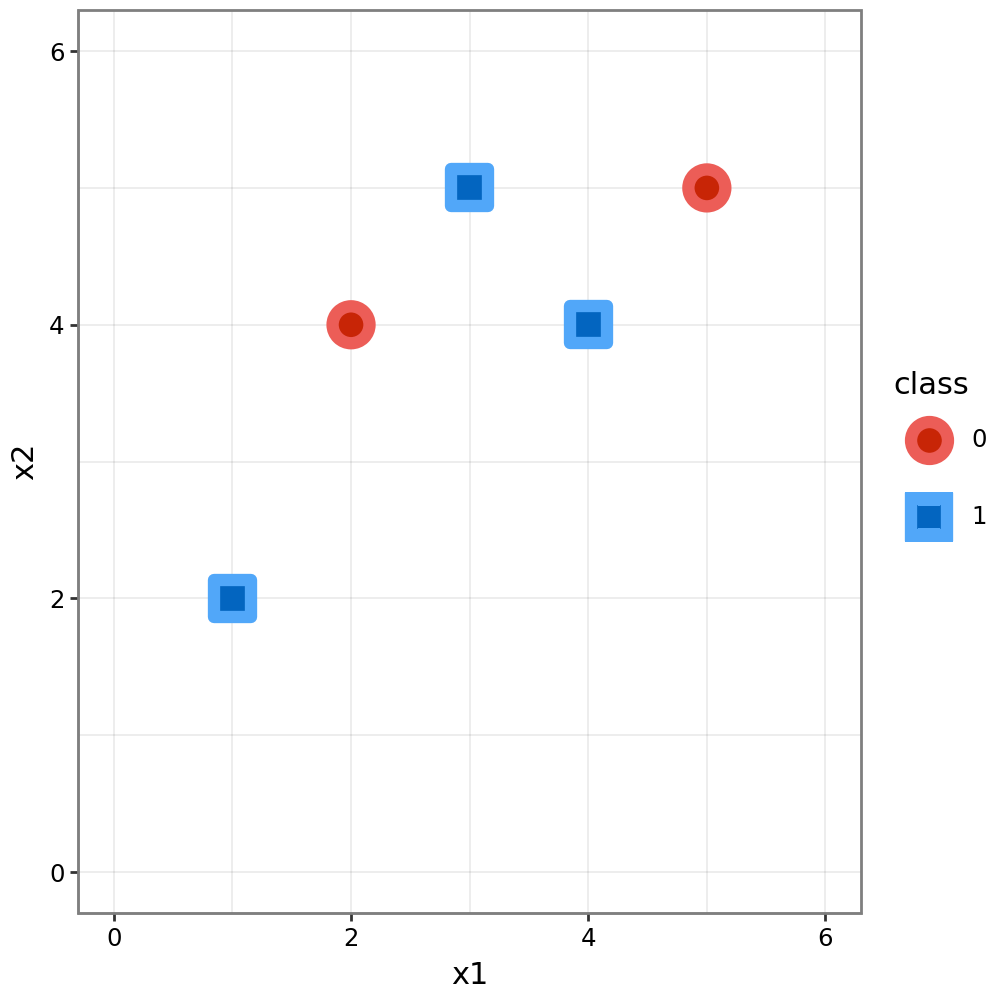

In [52]:
example_data = pd.DataFrame({'x1':[1,2,3,4,5], 'x2':[2,4,5,4,5], 'class':[1,0,1,1,0]})
example_data['class'] = example_data['class'].astype('category') # note that we turn class into categories

# categorical means numbers with labels

draw_points_ggplot2(example_data)

Let's see how the usual decision tree would look like on this data.


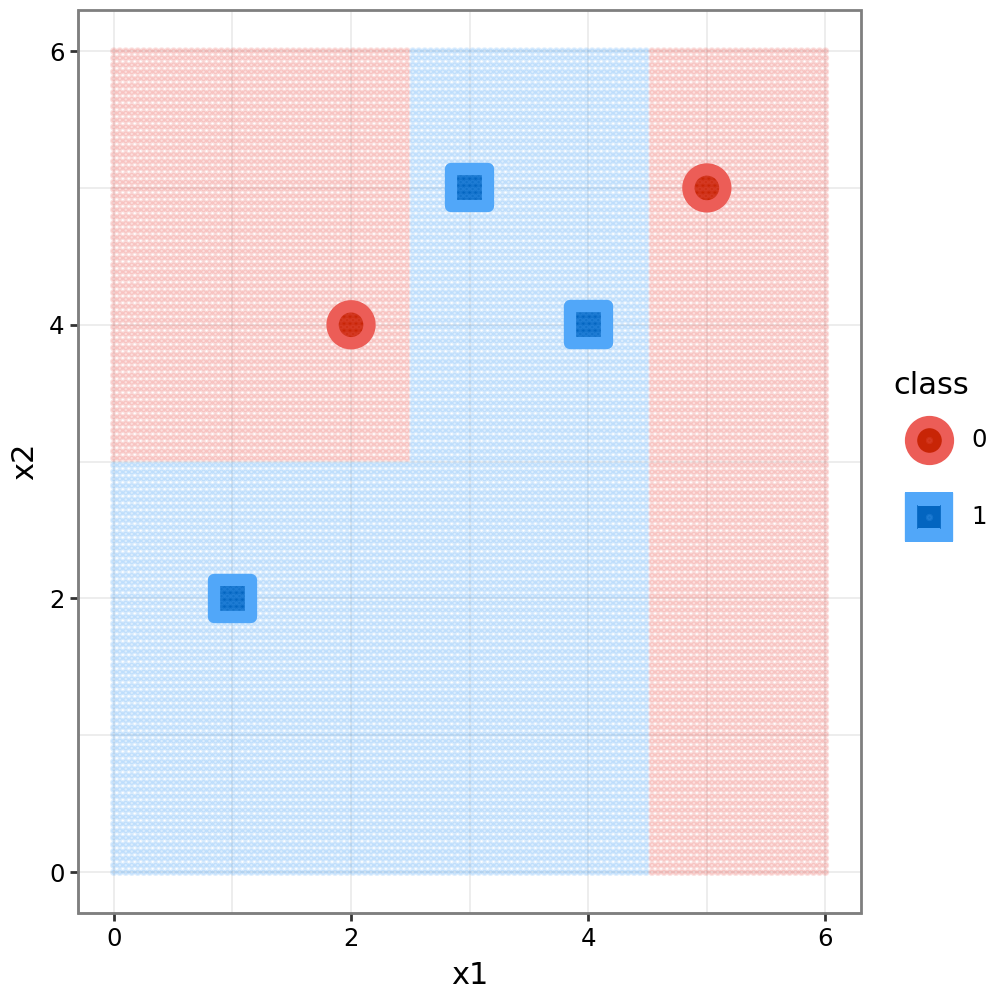

In [53]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

# training a decision tree classifier on example data
dt.fit(example_data[['x1', 'x2']], example_data[['class']])

# predicting grid data
grid_data['dt'] = dt.predict(grid_data[['x1', 'x2']])

# visualise the initial egalitarian tree
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(dt)'),  size = .5, alpha = 0.2)

Here we shall build a boosting ensemble. Let's build the first decision stump:


In [54]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier(max_depth=1) # remember that it can only have 1 level

In [55]:
initial_weights = np.ones(len(example_data)) # egalitarian world
print(initial_weights)

np.random.seed(1111)

model1.fit(example_data[['x1', 'x2']], example_data[['class']], sample_weight = initial_weights)

[1. 1. 1. 1. 1.]


,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


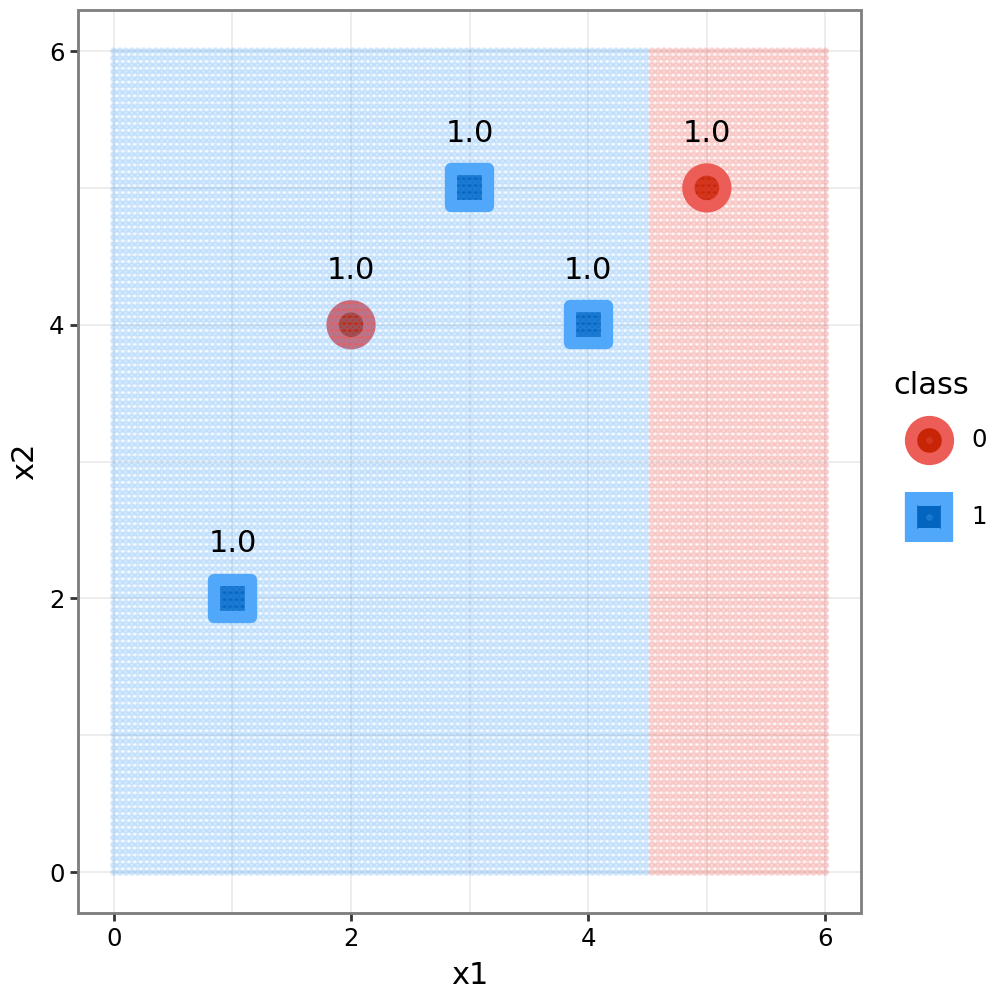

In [56]:
grid_data['model1'] = model1.predict(grid_data[['x1', 'x2']])

# visualise the initial egalitarian tree
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(model1)'),  size = .5, alpha = 0.2) + geom_text(aes(label = initial_weights), nudge_y = 0.4)

In [57]:
grid_data

,x1,x2,dt,model1
0,0.000000,0.0,1,1
1,0.050420,0.0,1,1
2,0.100840,0.0,1,1
3,0.151261,0.0,1,1
4,0.201681,0.0,1,1
...,...,...,...,...
14395,5.798319,6.0,0,0
14396,5.848739,6.0,0,0
14397,5.899160,6.0,0,0
14398,5.949580,6.0,0,0


In [58]:
example_data

,x1,x2,class
0,1,2,1
1,2,4,0
2,3,5,1
3,4,4,1
4,5,5,0


In [59]:
incorrect = ( model1.predict(example_data[['x1', 'x2']]) ) != example_data['class']
print(np.array(incorrect))

[False  True False False False]


In [60]:
np.array(~incorrect)   # flips boolen values 0 -> 1 and 1 -> 0

array([ True, False,  True,  True,  True])

**Exercise** update the weights as discussed in the lecture (add score of 0.5 to those points that were misclassified and remove 0.5 from classified correctly)


In [61]:
new_weights = initial_weights.copy()

##### YOUR CODE STARTS #####
new_weights[np.array(~incorrect)] -= 0.5  # correct prediction
new_weights[np.array(incorrect)] += 0.5	  # incorrect prediction
##### YOUR CODE ENDS #####

print(new_weights)

[0.5 1.5 0.5 0.5 0.5]


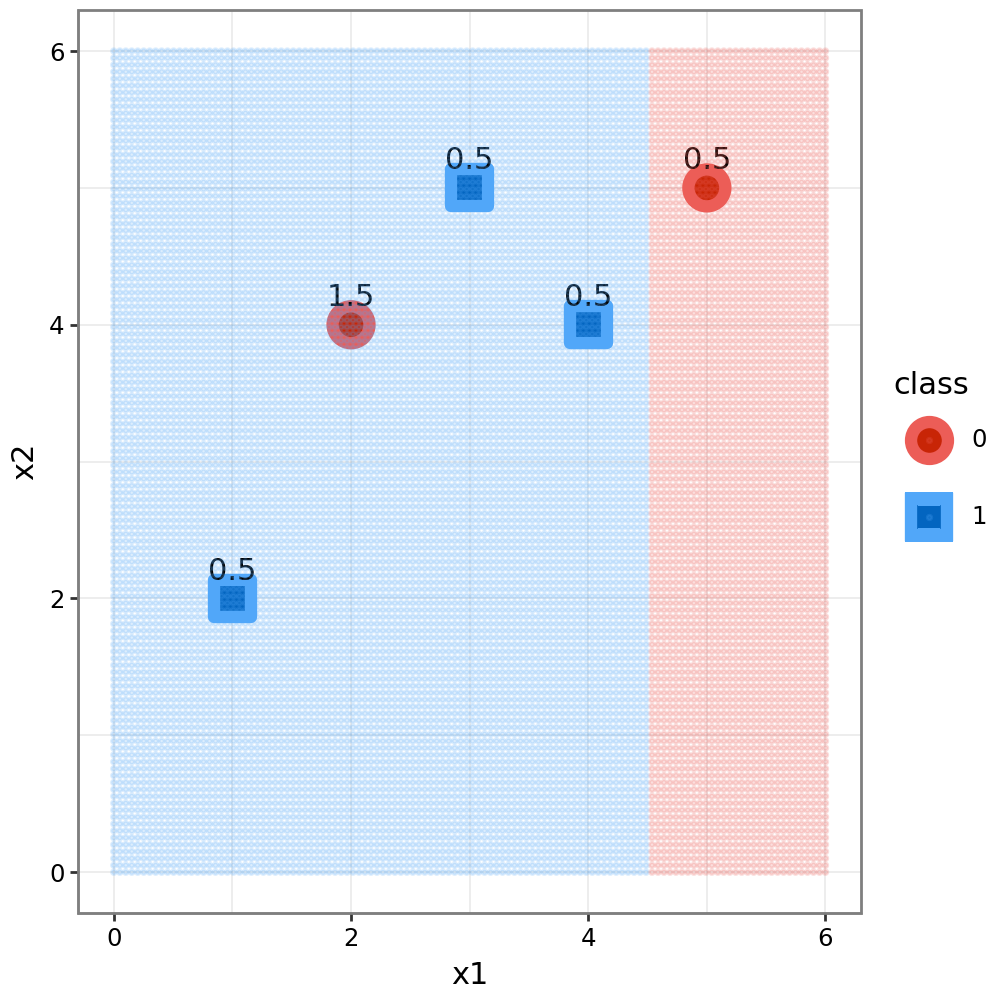

In [62]:
draw_points_ggplot2(example_data) + geom_text(aes(label = new_weights), nudge_y = 0.2) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(model1)'),  size = .5, alpha = 0.2)

**Exercise** Repeat the same process for models #2 and #3.


Let's build the second tree using these new weights


In [63]:
np.random.seed(1111)
##### YOUR CODE STARTS #####
model2 = DecisionTreeClassifier(max_depth=1)
model2.fit(example_data[['x1', 'x2']], example_data[['class']], sample_weight = new_weights)
##### YOUR CODE ENDS #####

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualising boundaries of the second tree:


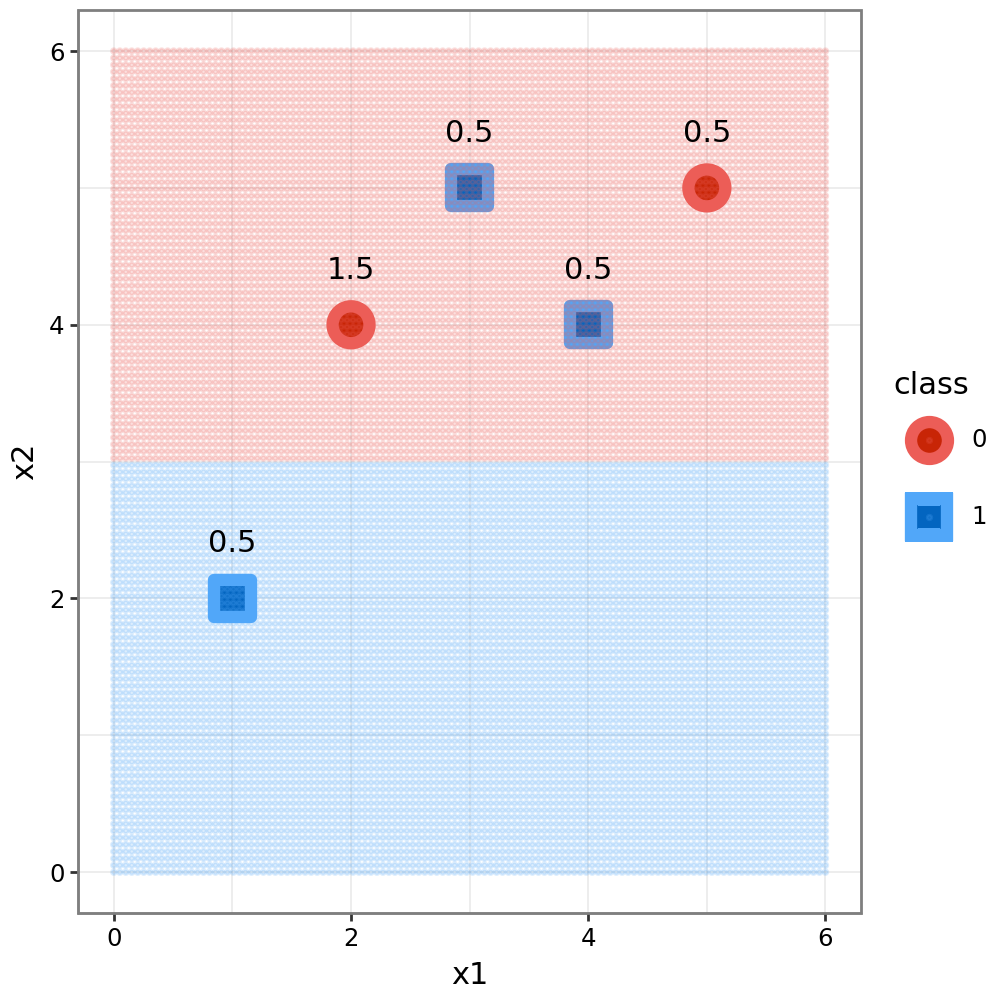

In [64]:
##### YOUR CODE STARTS #####
grid_data['model2'] = model2.predict(grid_data[['x1', 'x2']])
##### YOUR CODE ENDS #####
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(model2)'),  size = .5, alpha = 0.2) + geom_text(aes(label = new_weights), nudge_y = 0.4)

In [65]:
##### YOUR CODE STARTS #####
incorrect = model2.predict(example_data[['x1', 'x2']]) != example_data['class']
##### YOUR CODE ENDS #####

print(np.array(incorrect))

[False False  True  True False]


Changing the weights for the second time:


In [66]:
##### YOUR CODE STARTS #####
newer_weights = new_weights.copy()
newer_weights[np.array(incorrect)] += 0.5
newer_weights[np.array(~incorrect)] -= 0.5
##### YOUR CODE ENDS #####
print(newer_weights)

[0. 1. 1. 1. 0.]


In [67]:
np.random.seed(1111)

model3 = DecisionTreeClassifier(max_depth=1)
##### YOUR CODE STARTS #####
model3.fit(example_data[['x1', 'x2']], example_data[['class']], sample_weight = newer_weights)
##### YOUR CODE ENDS #####

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualising the decision boundaries of the third tree


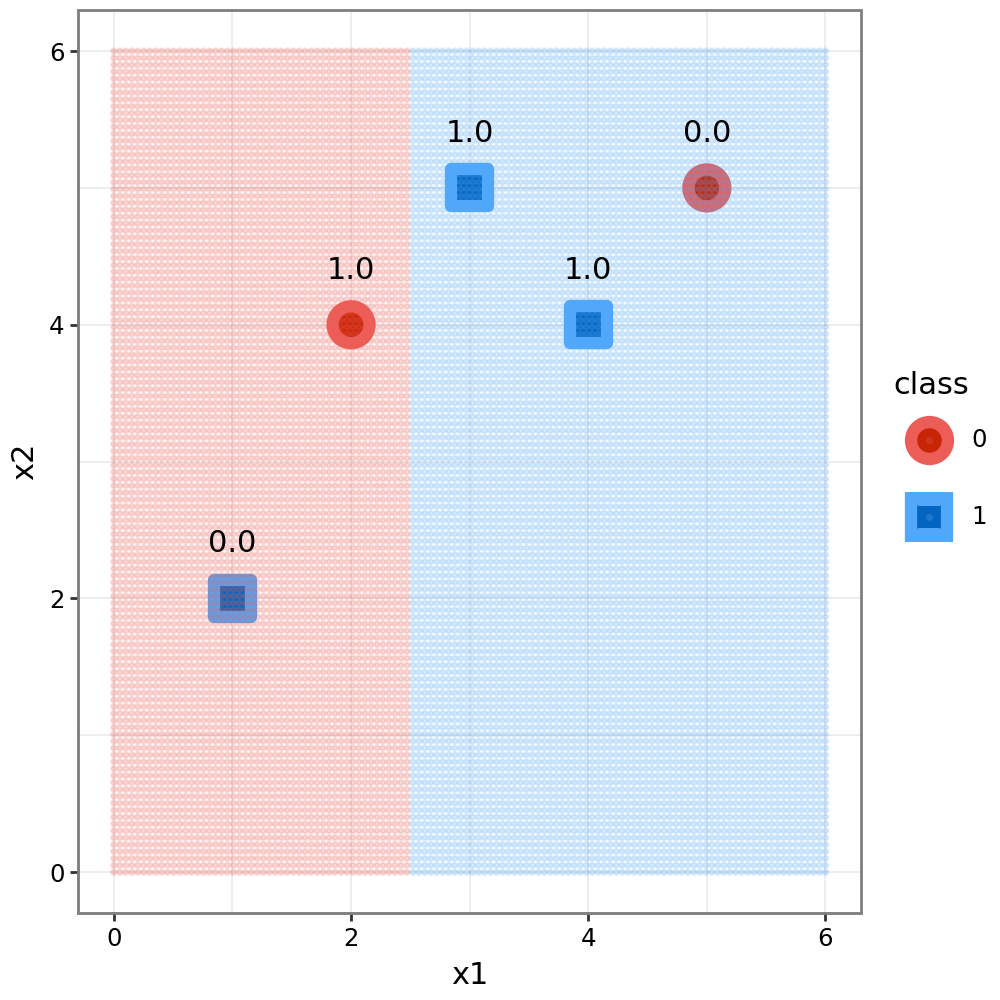

In [68]:
##### YOUR CODE STARTS #####
grid_data['model3'] = model3.predict(grid_data[['x1', 'x2']])
##### YOUR CODE ENDS #####
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(model3)'),  size = .5, alpha = 0.2) + geom_text(aes(label = newer_weights), nudge_y = 0.4)

Putting all these trees together into one model


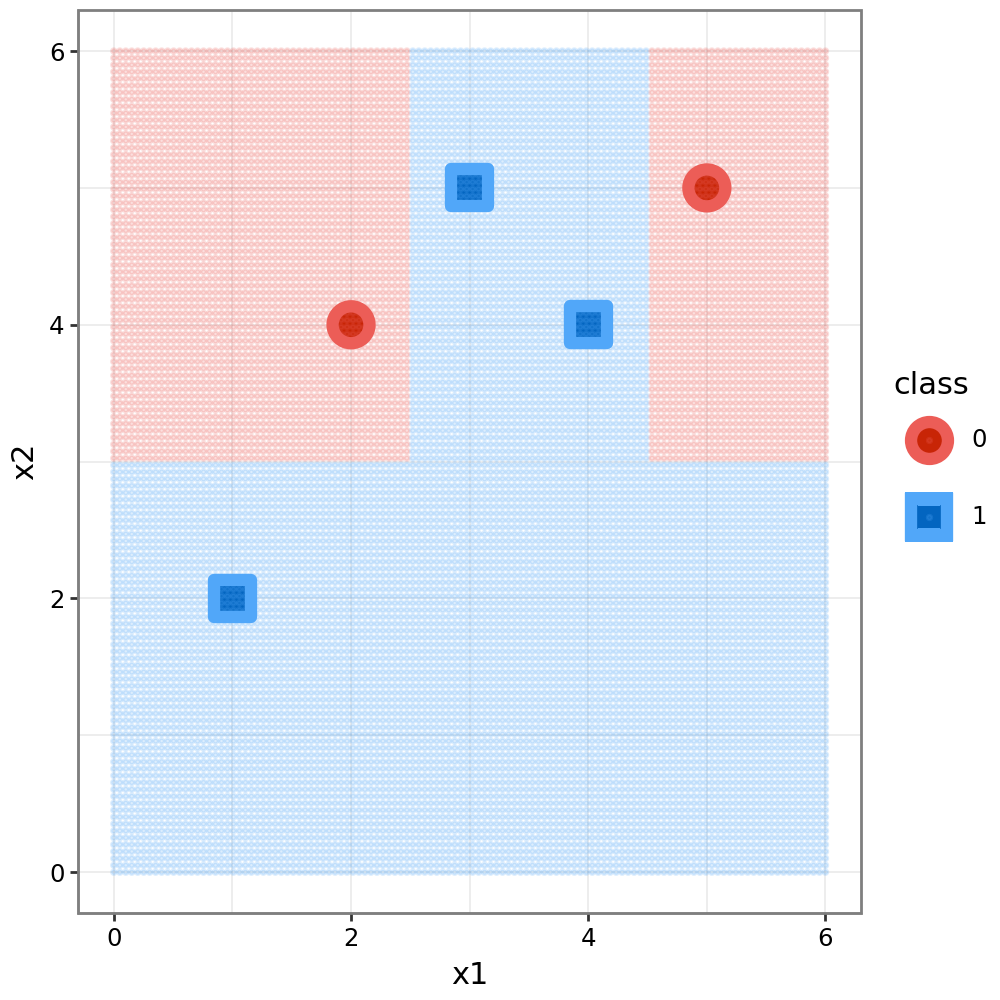

In [69]:
grid_data['ensemble'] = grid_data[['model1', 'model2', 'model3']].mode(axis = 1)
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(ensemble)'),  size = .5, alpha = 0.2)

Let's compare to the official `AdaBoostClassifier` implmentation from the `sklearn`. Pay attention to the parameters, we want 3 models, with each one of them being `DecisionTreeClassifier` with `max_depth = 1`.


In [70]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=3, estimator=DecisionTreeClassifier(max_depth=1), random_state=3)

# train AdaBoost on our data
np.random.seed(1111)
model.fit(example_data[['x1','x2']], example_data[['class']])

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,3
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,3
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


Here we visualise AdaBoost decision boundaries


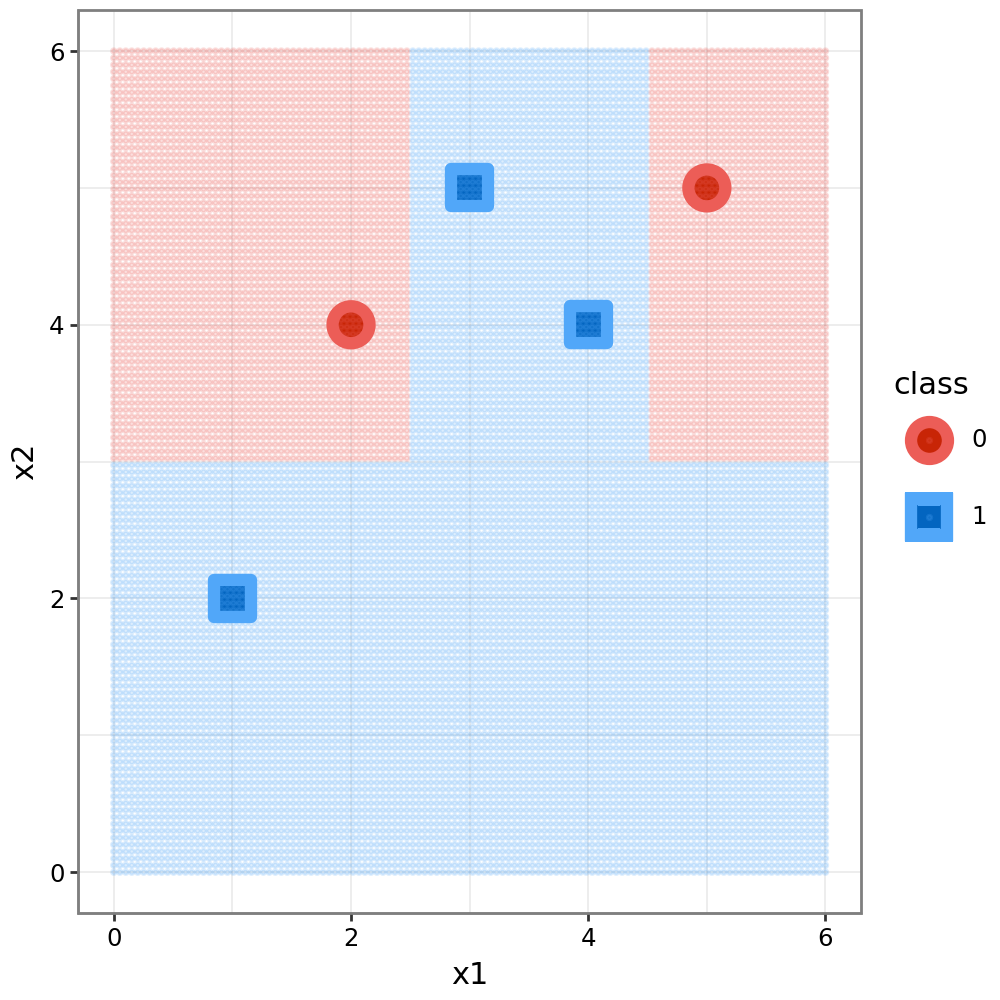

In [71]:
grid_data['ada_ensemble'] = model.predict(grid_data[['x1', 'x2']])
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(ada_ensemble)'),  size = .5, alpha = 0.2)

## Gradient boosting machines (GBM)

Here we will be training a gradient boosting machine on the decision stumps. We will start by assuming that the problem we are dealing with is a regression, but transform the resulting model into a classifier at the end.


In [72]:
example_data = pd.DataFrame({'x1':[1,2,3,4,5], 'x2':[2,4,5,4,5], 'class':[1,0,1,1,0]})
# note that now we actually don't turn "class" into categorical
# we will treat this problem as regreession now

Fit the first **`DecisionTreeRegressor`** model on the original data. I have not found any restrictions on the size of the tree for the gradient boosting algorithm, but let's keep decision stumps as before.


In [73]:
from sklearn.tree import DecisionTreeRegressor
model1 = DecisionTreeRegressor(max_depth=1) # let's keep 1 level trees

# DecisionTreeClassifier vs DecisionTreeRegressor?


np.random.seed(111)

model1.fit(example_data[['x1', 'x2']], example_data[['class']])

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Now, let's predict the data using this first tree


In [74]:
predictions_model1 = model1.predict(example_data[['x1','x2']])
print(f'predictions of the first tree: {predictions_model1}')

predictions of the first tree: [0.75 0.75 0.75 0.75 0.  ]


Find the residuals (subtract predictions from the ground truth)


In [75]:
errors_model1 = example_data['class'] - predictions_model1
print(f'residuals: {np.array(errors_model1)}')

residuals: [ 0.25 -0.75  0.25  0.25  0.  ]


Now use these errors as a `target` for the second tree!


In [76]:
np.random.seed(1111)

model2 = DecisionTreeRegressor(max_depth=1)
model2.fit(X = example_data[['x1', 'x2']], y = errors_model1)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


**Exercise** implement the same procedure for the second and third models


In [77]:
##### YOUR CODE STARTS #####
predictions_model2 = model2.predict(example_data[['x1', 'x2']])
##### YOUR CODE ENDS #####
print(f'predictions of the second tree: {predictions_model2}')

predictions of the second tree: [-0.25       -0.25        0.16666667  0.16666667  0.16666667]


Add these to the predictions obtained by the first model. Subtract the resulting sum from the ground truth.


In [78]:
##### YOUR CODE STARTS #####
errors_model2 = errors_model1 - predictions_model2
##### YOUR CODE ENDS #####
print(f'residuals: {np.array(errors_model2)}')

residuals: [ 0.5        -0.5         0.08333333  0.08333333 -0.16666667]


Do the same for the last third tree


In [79]:
np.random.seed(1111)

##### YOUR CODE STARTS #####
model3 = DecisionTreeRegressor(max_depth=1)
model3.fit(X = example_data[['x1', 'x2']], y = errors_model2)
##### YOUR CODE ENDS #####

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [80]:
##### YOUR CODE STARTS #####
predictions_model3 = model3.predict(example_data[['x1', 'x2']])
##### YOUR CODE ENDS #####
print(f'predictions of the first tree: {predictions_model3}')

predictions of the first tree: [ 0.5   -0.125 -0.125 -0.125 -0.125]


In [81]:
##### YOUR CODE STARTS #####
errors_model3 = errors_model2 - predictions_model3
##### YOUR CODE ENDS #####
print(f'residuals: {np.array(errors_model3)}')

residuals: [ 0.         -0.375       0.20833333  0.20833333 -0.04166667]


In [82]:
grid_data['gbm'] = model1.predict(grid_data[['x1', 'x2']]) + model2.predict(grid_data[['x1', 'x2']]) + model3.predict(grid_data[['x1', 'x2']])

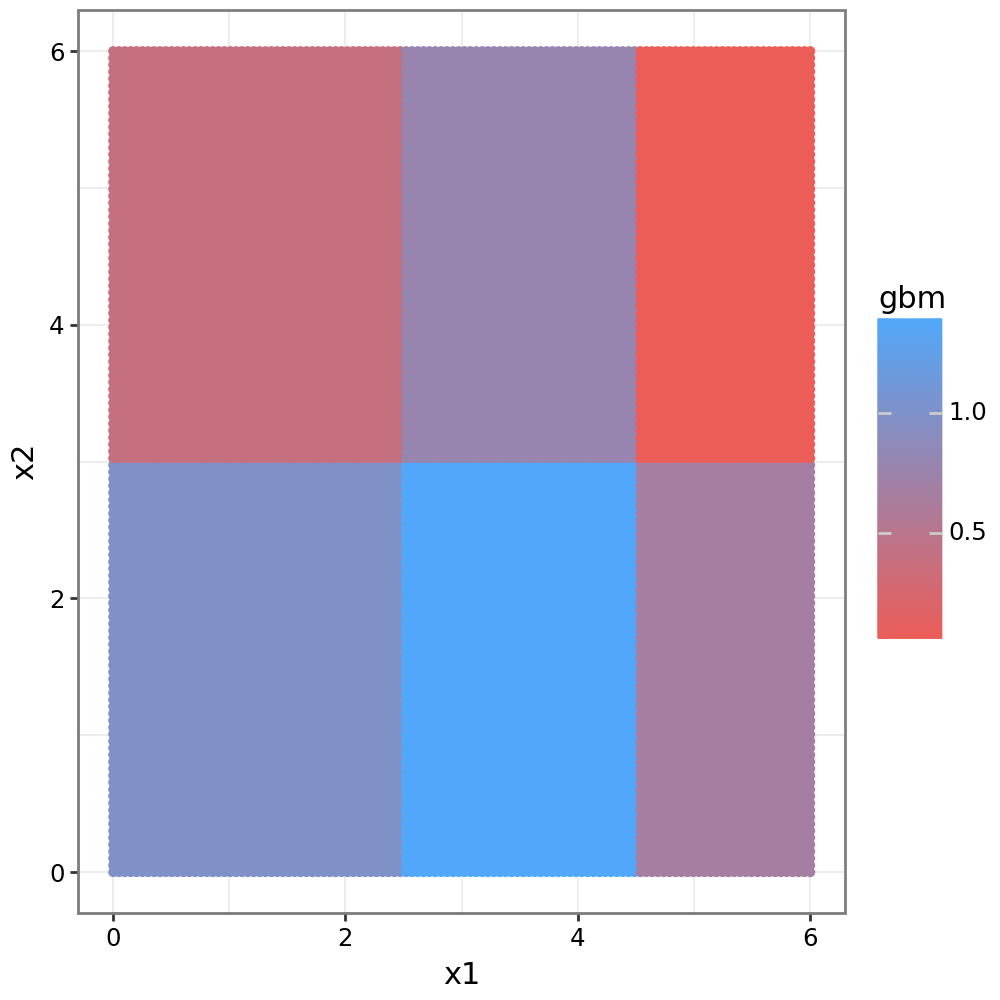

In [83]:
fig = (
    ggplot(data = grid_data,
          mapping = aes(x = 'x1', y = 'x2')) +
    geom_point(aes(colour = 'gbm'),
               size = 1.0) +
    labs(
        title ='',
        x = 'x1',
        y = 'x2',
    ) +
    theme_bw() +
    scale_colour_gradientn(['#EC5D57', '#51A7F9']) +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black'))
  )
fig

In [84]:
grid_data['gbm_class'] = 0
grid_data.loc[grid_data['gbm'] >= 0.5, 'gbm_class'] = 1

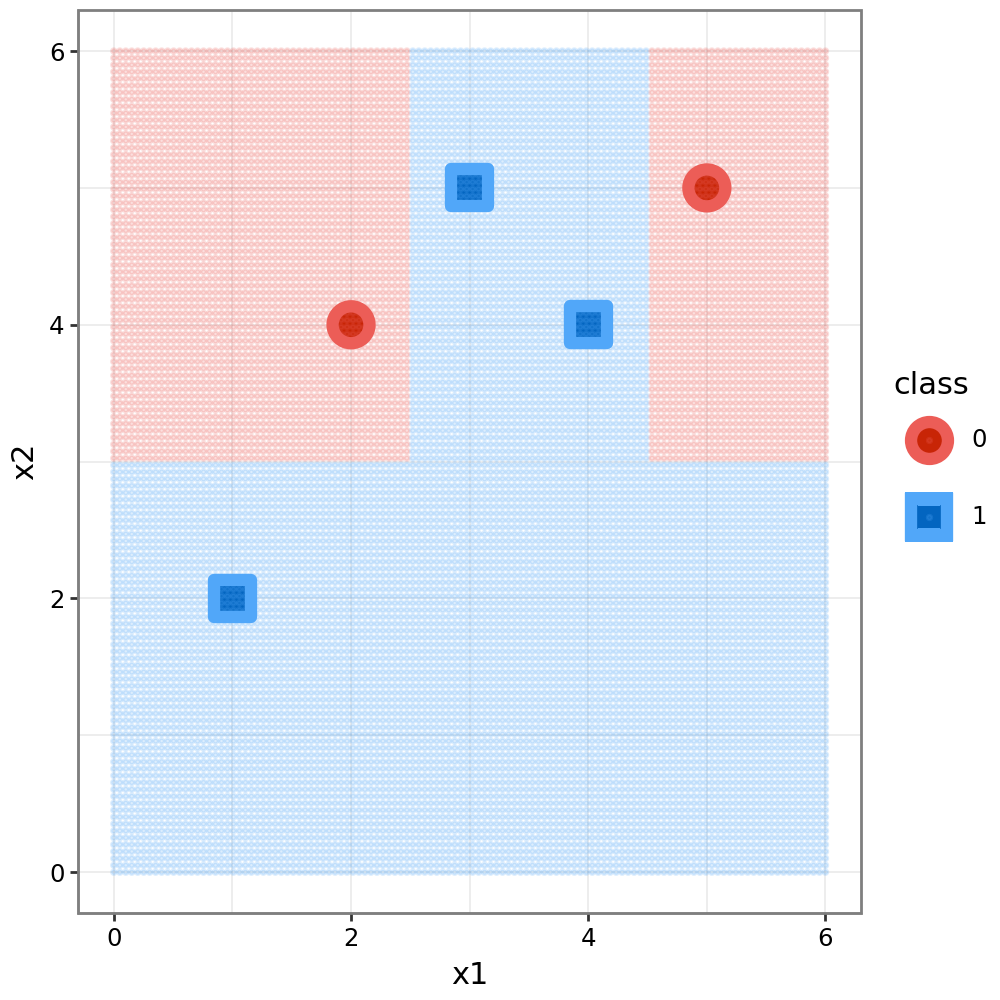

In [85]:
example_data['class'] = example_data['class'].astype('category') # now we can cast `class` back into categorical
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(gbm_class)'),  size = .5, alpha = 0.2)

In [86]:
# BGM is part of XGBoost - its pretty prone to over-fitting

### Gradient Boosting from sklearn (just verify the results)


In [87]:
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=3, random_state=1) # uses DecisionTreeRegressor by default

# train GBM on our data
np.random.seed(1111)
gbm.fit(example_data[['x1','x2']], example_data[['class']])

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


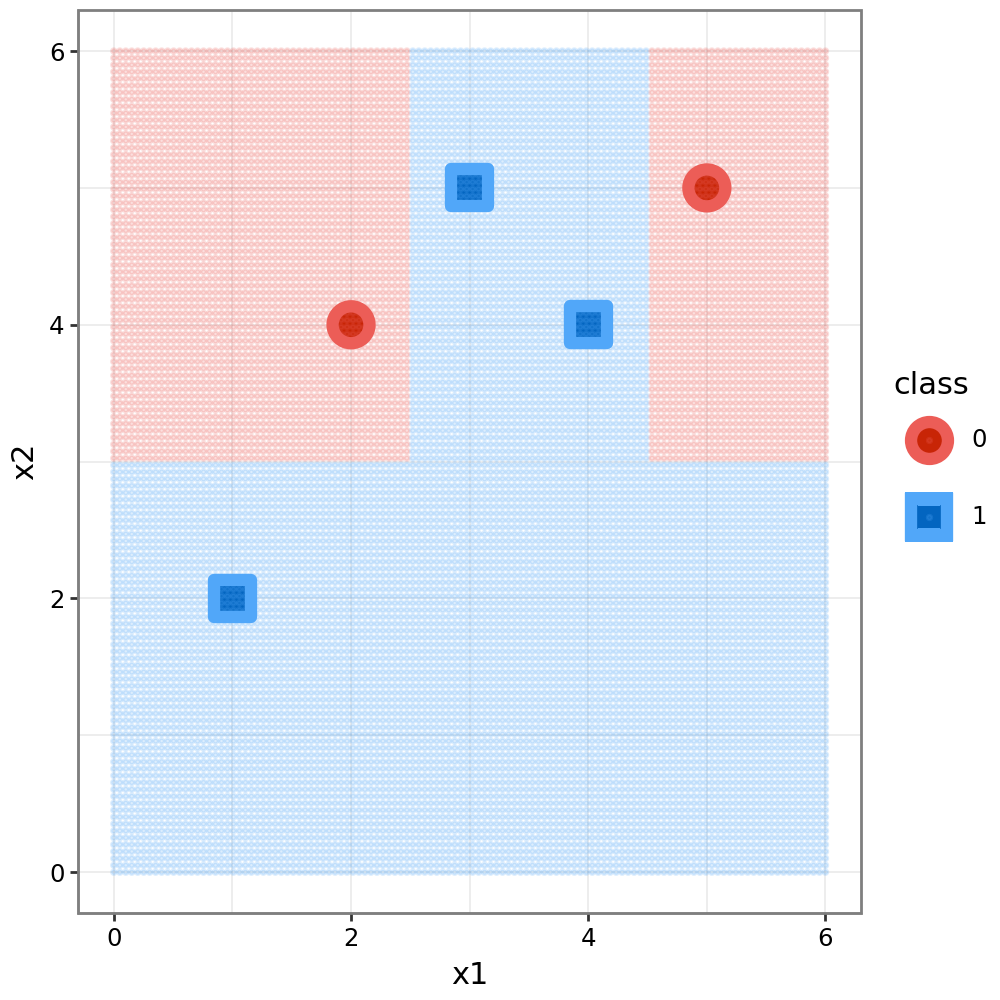

In [88]:
grid_data['gbm_ensemble'] = model.predict(grid_data[['x1', 'x2']])
draw_points_ggplot2(example_data) + geom_point(data = grid_data, mapping = aes(x = 'x1', y = 'x2', colour = 'factor(gbm_ensemble)'),  size = .5, alpha = 0.2)

In [89]:
# L1 - adding sum of abs weights as optimisation criteria
# L2 - adding sum of squared abs weights as optimisation criteria


# how to regualize DT.
# 	- ammount of leaf nodes or the dept?

# 	- L1/L2 like reg in DT:
#		what is the smallest number of points that should fit in to a leaf.
#			You dont want to have only 1 point in a leaf, its over-fitting then.
# 		XGBoost is doing this!! no 1 point in leaf!!!

# Stacking

On top of everything we have seen, you can still improve the results by training the meta-learner (meta-model) that would use predictions of other models as input.


In [ ]:
# train meta approach on top of the predictions of base models (base estimators/weak learners)

In [90]:
from tensorflow.keras.datasets import mnist
(images, labels), _ = mnist.load_data()

# reshape into a matrix format
images = images.reshape(-1, 28*28)

# use fewer images for faster training
train_images = images[0:2000]
train_labels = labels[0:2000]

test_images = images[2000:3000]
test_labels = labels[2000:3000]

First we should again train familiar three models


In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

model1 = DecisionTreeClassifier()
model2 = KNeighborsClassifier()
model3 = LogisticRegression()

np.random.seed(1111)
model1.fit(train_images, train_labels)

np.random.seed(1111)
model2.fit(train_images, train_labels)

np.random.seed(1111)
model3.fit(train_images, train_labels)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


We can go ahead and test these machine learning models on the test data


In [92]:
model1_pred = model1.predict(test_images)
model2_pred = model2.predict(test_images)
model3_pred = model3.predict(test_images)

print(f"Accuracy of DT {model1.score(test_images, test_labels)*100}%")
print(f"Accuracy of NN {model2.score(test_images, test_labels)*100}%")
print(f"Accuracy of LR {model3.score(test_images, test_labels)*100}%")

Accuracy of DT 76.6%
Accuracy of NN 91.2%
Accuracy of LR 88.0%


In [ ]:
# We train meta dataset on class preditions (class probabilities) from all of the base models... not actual train/test data!!!!

# all probs should sum up to 1 (soft max!!)

Classical stacking, we need to run CV algorithm and record predictions made by each model on the hold out data. Then we will use theses predictions as training data for the meta-learner.


In [ ]:
from sklearn.model_selection import StratifiedKFold

hold_out_pred_model1 = []
hold_out_pred_model2 = []
hold_out_pred_model3 = []

n_folds = 4

X = np.array(train_images)
y = np.array(train_labels)

# initialise splitting mechanism
folds = StratifiedKFold(n_splits=n_folds, shuffle = False) # no need to shuffle the data

# here actual splitting is done
folds.get_n_splits(X, y)

fold_indx = 1

# Stacking model



# folds.split is an iterator that loops over different folds
# returning a tuple with train and val indeces
for train_index, val_index in folds.split(X, y):
  print(f"CV #{fold_indx}")
  X_train, X_val = X[train_index], X[val_index]
  y_train, y_val = y[train_index], y[val_index]

  # We are not re-using data between folds!!! no leakage!!!
  # and we are not resuing the same model, we are always creating a new one
  model1 = DecisionTreeClassifier()
  model2 = KNeighborsClassifier()
  model3 = LogisticRegression()

  # train all three models
  model1.fit(X_train, y_train)
  model2.fit(X_train, y_train)
  model3.fit(X_train, y_train)

  # make predictions on hold out set
  hold_out_pred_model1.extend(model1.predict_proba(X_val)) # we use predict_proba function to get a vector of probabilities for each class
  # predict() just gives to class but this gives probabilities for each class for 1 image

  hold_out_pred_model2.extend(model2.predict_proba(X_val))
  hold_out_pred_model3.extend(model3.predict_proba(X_val))

  fold_indx += 1

CV #1
CV #2
CV #3
CV #4


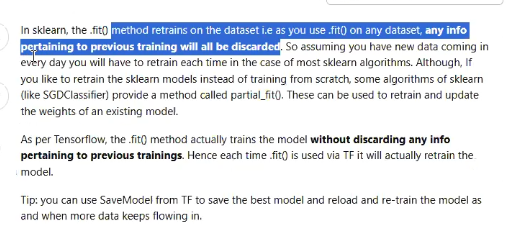


Let's concatenate all these predictions into one dataset. Each model outputs probabilities for each class (there are 10 classes in the dataset), which means that for each digit (2000 in the training data) we will have 10 values from each model, which adds up to 30 values in total (from 3 models).


In [ ]:
# We dont do this, because its trained that is not realistic
# you and training and predicting on the same data

#model1.fit(train_data)
#hold_out_pred_model1 = model1.predict_proba(train_data)

In [125]:
train_stacking = np.concatenate([hold_out_pred_model1,
                                 hold_out_pred_model2,
                                 hold_out_pred_model3],
                                axis = 1)
train_stacking.shape

(2000, 30)

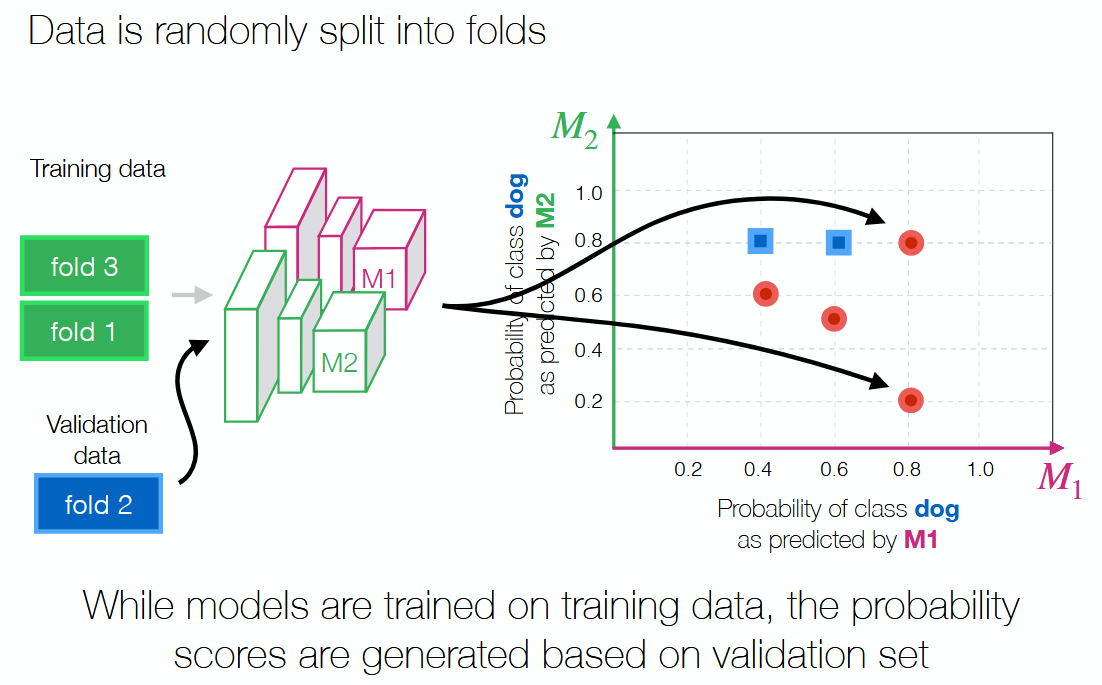


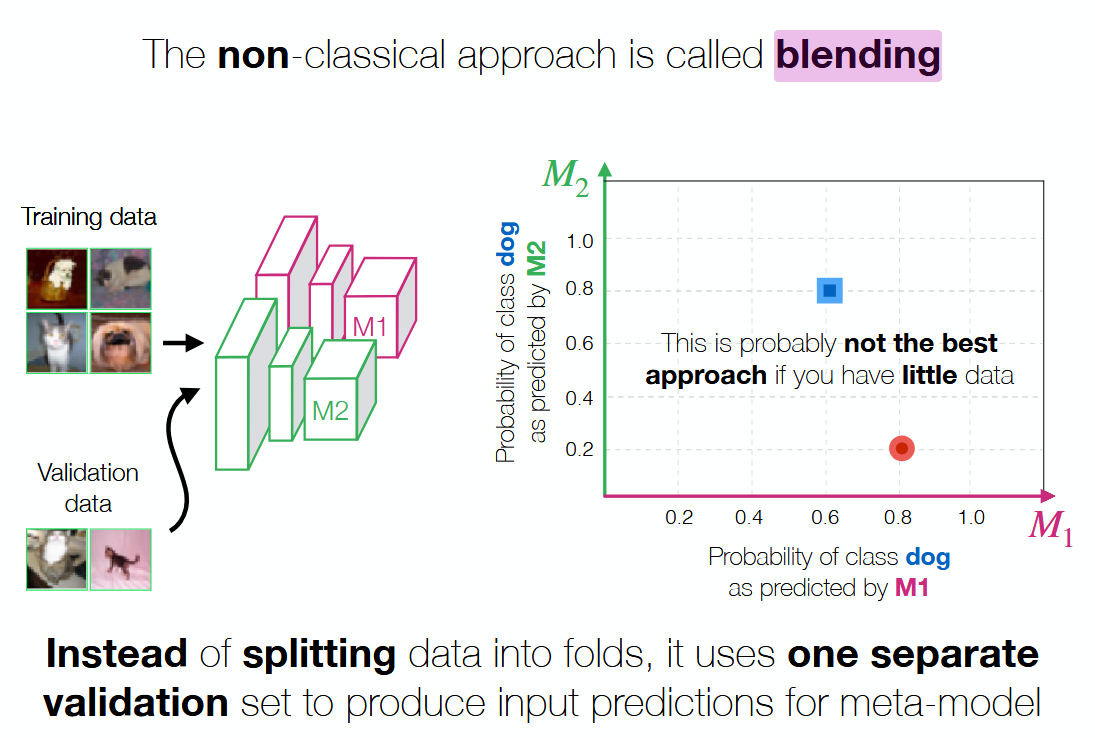


We need also a test set for the stacking model, but this is simpler


In [126]:
# re-training the models on the entire training data
np.random.seed(1111)
model1.fit(train_images, train_labels)

np.random.seed(1111)
model2.fit(train_images, train_labels)

np.random.seed(1111)
model3.fit(train_images, train_labels)

# predicting the test images using these models
model1_pred = model1.predict_proba(test_images)
model2_pred = model2.predict_proba(test_images)
model3_pred = model3.predict_proba(test_images)

test_stacking = np.concatenate([model1_pred,
                                model2_pred,
                                model3_pred],
                                axis = 1)

test_stacking.shape

(1000, 30)

Train a meta-model (e.g. Support Vector Classifier, Logistic Regression or Decision Tree or something else) using these predictions as training data.


In [127]:
from sklearn.svm import SVC
stacking_model = SVC()

np.random.seed(1111)
stacking_model.fit(train_stacking, train_labels)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [128]:
print(f"Accuracy of stacking ensemble {stacking_model.score(test_stacking, test_labels)*100}%")

Accuracy of stacking ensemble 92.4%


<br>


In [ ]:
# My code :) vvv

In [131]:
m_dt = DecisionTreeClassifier(max_depth=9) # max_depth 11 or 9 are best

np.random.seed(1111)
m_dt.fit(train_stacking, train_labels)
print(f"Accuracy of stacking ensemble (DT) {m_dt.score(test_stacking, test_labels)*100}%")

Accuracy of stacking ensemble (DT) 84.6%


In [133]:
m_log_reg = LogisticRegression()

np.random.seed(1111)
m_log_reg.fit(train_stacking, train_labels)
print(f"Accuracy of stacking ensemble (LogReg) {m_log_reg.score(test_stacking, test_labels)*100}%")

Accuracy of stacking ensemble (LogReg) 92.9%


### Sklearn implementation of Stacking

Of course, sklearn can do it for you :)


In [134]:
from sklearn.ensemble import StackingClassifier
np.random.seed(1111)
estimators = [('decision_tree', DecisionTreeClassifier()),
              ('knn', KNeighborsClassifier()),
              ('log_reg', LogisticRegression())]

stacking_classifier = StackingClassifier(estimators=estimators, final_estimator=SVC(), cv=n_folds)
stacking_classifier.fit(train_images, train_labels)
print(f"Accuracy of sklearn stacking ensemble {stacking_classifier.score(test_images, test_labels)*100}%")

Accuracy of sklearn stacking ensemble 92.80000000000001%


In [135]:
print(f"Accuracy of manual stacking ensemble {stacking_model.score(test_stacking, test_labels)*100}%")

Accuracy of manual stacking ensemble 92.4%
